In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

import tensorflow as tf
tf.config.experimental.set_memory_growth(tf.config.list_physical_devices(device_type="GPU")[0], True)

from deep_lss.models.base_model import BaseModel
from deep_lss.utils import configuration
from deep_lss.nets import NETWORKS
from msi.utils import preprocessing
from msfm.utils import prior, parameters, files, logger, observation

# v9

### clustering

In [3]:
msfm_conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v9/linear_bias.yaml")
base_dir = "/pscratch/sd/a/athomsen/run_files/v9/clustering"

In [4]:
# earnest-wood-1039 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/nmhf2f7f), 10% of noise
model_dir = "delta/2024-07-17_09-27-28_resnet_vanilla"
net_conf = "/global/u2/a/athomsen/y3-deep-lss/configs/v9/clustering/resnet_vanilla.yaml"
dlss_conf = configuration.load_deep_lss_config(
    "/global/u2/a/athomsen/y3-deep-lss/configs/v9/clustering/linear_bias/dlss_config_10.yaml"
)
n_steps = 60_000

24-07-25 06:06:24 configuratio INF   Loaded the config 


In [5]:
# # fresh-sky-1040 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/0r0mzpo9), 1% of noise
# model_dir = "delta/2024-07-18_10-16-57_resnet_vanilla"
# net_conf = "/global/u2/a/athomsen/y3-deep-lss/configs/v9/clustering/resnet_vanilla.yaml"
# dlss_conf = configuration.load_deep_lss_config(
#     "/global/u2/a/athomsen/y3-deep-lss/configs/v9/clustering/linear_bias/dlss_config.yaml"
# )
# n_steps = 60_000

In [6]:
loss_func = "delta"
net_conf = configuration.load_deep_lss_config(net_conf)
data_vec_pix = files.load_pixel_file(msfm_conf)[0]
params = ["Om", "s8", "w0", "bg", "n_bg"]
n_z = 4

24-07-25 06:06:24 configuratio INF   Loaded the config 
24-07-25 06:06:25     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_512.h5 


# build the network

In [7]:
smoothing_kwargs = configuration.get_smoothing_kwargs(
    loss_func, msfm_conf, dlss_conf, net_conf, dir_base="."
)

# load the layers
network = NETWORKS[net_conf["network"]["name"]](
    out_features=len(params), smoothing_kwargs=smoothing_kwargs, **net_conf["network"]["kwargs"]
).get_layers()

# build the model, same regardless of the loss function (fiducial or grid)
model = BaseModel(
    network=network,
    n_side=msfm_conf["analysis"]["n_side"],
    indices=data_vec_pix,
    n_neighbors=net_conf["network"]["n_neighbors"],
    input_shape=(None, len(data_vec_pix), n_z),
    checkpoint_dir=os.path.join(base_dir, model_dir, "checkpoint"),
    # always load from a checkpoint
    restore_checkpoint=True,
    strategy=None,
)

24-07-25 06:06:25     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_512.h5 
24-07-25 06:06:25     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_512.h5 
Using the per channel smoothing repetitions [6 3 2 1]
Using the per channel smoothing scales sigma = [29.65 20.96 17.12 12.1 ] arcmin, fwhm = [69.81 49.36 40.31 28.5 ] arcmin
Successfully loaded sparse kernel indices and values from ./smoothing
Successfully created the sparse kernel tensor
Adding white noise with sigma ListWrapper([2.07311547, 0.83312381, 0.63268587, 0.58193365]) to the smoothed map
24-07-25 06:06:32 regression_h INF   Using a dense regression head 
24-07-25 06:06:32 base_model.p INF   Initializing with a HealpyGCNN model 
Detected a reduction factor of 32.0, the input with nside 512 will be transformed to 16 during a forward pass. Checking for consistency with indices...
indices 

# forward model the mock

### weak lensing

### galaxy clustering

24-07-25 06:06:35     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_512.h5 
24-07-25 06:06:35     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_512.h5 


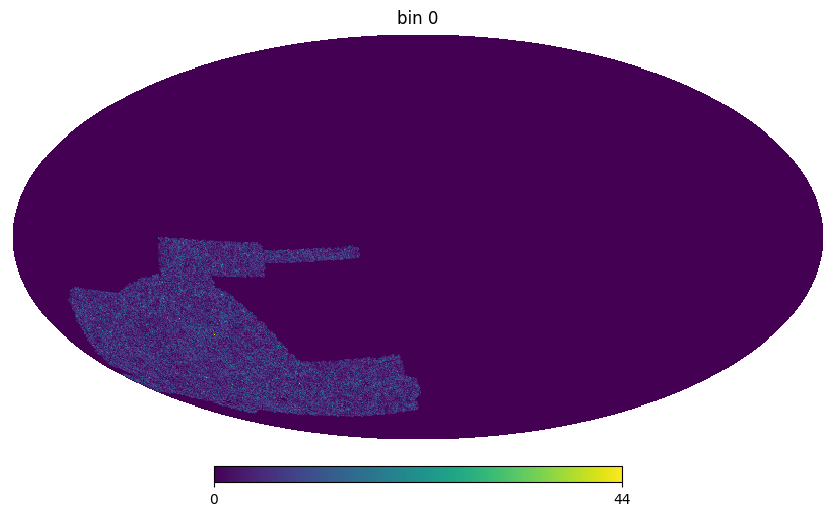

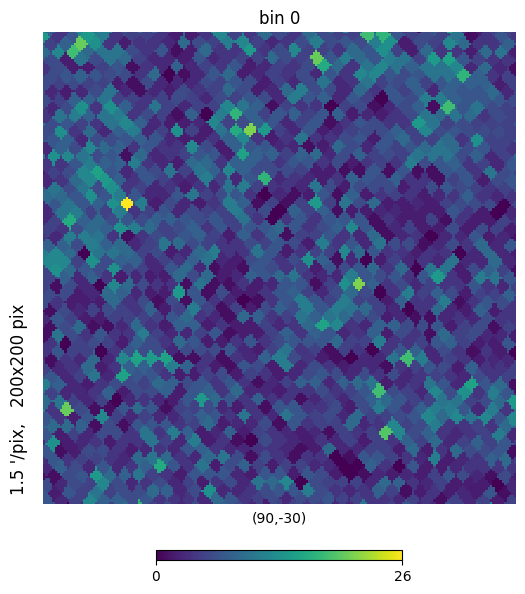

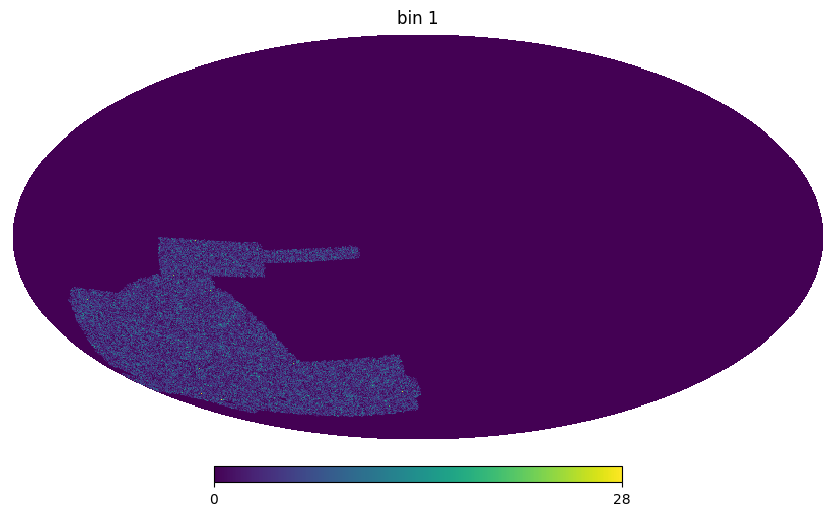

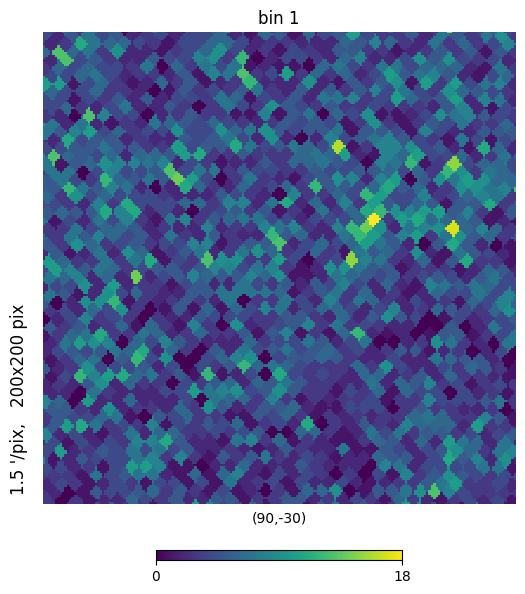

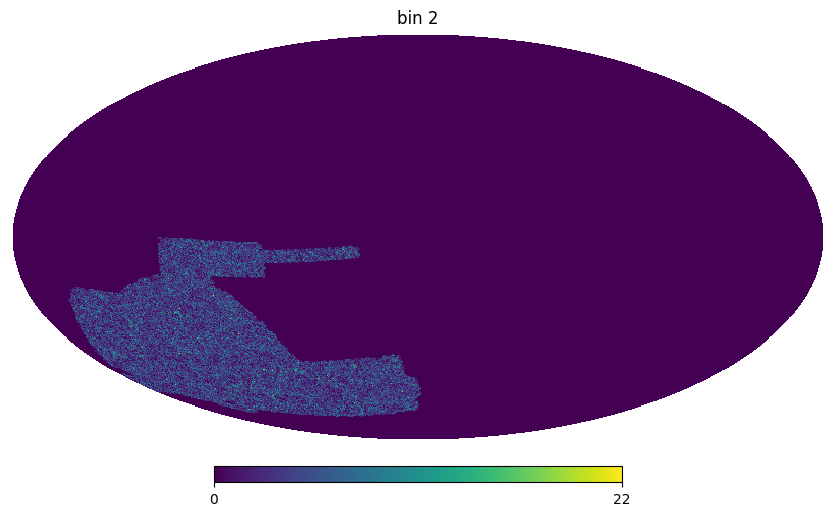

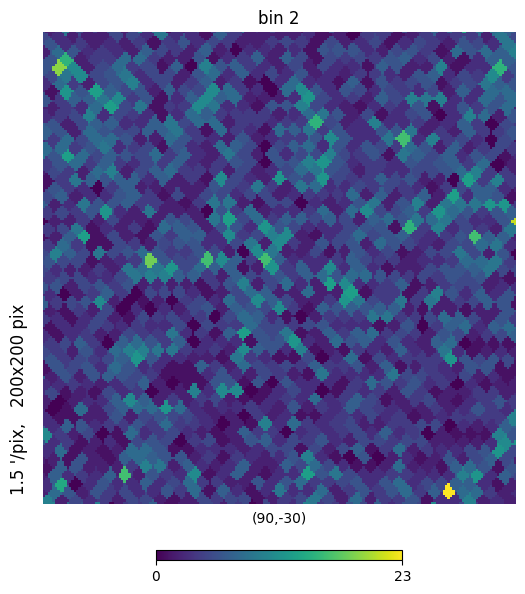

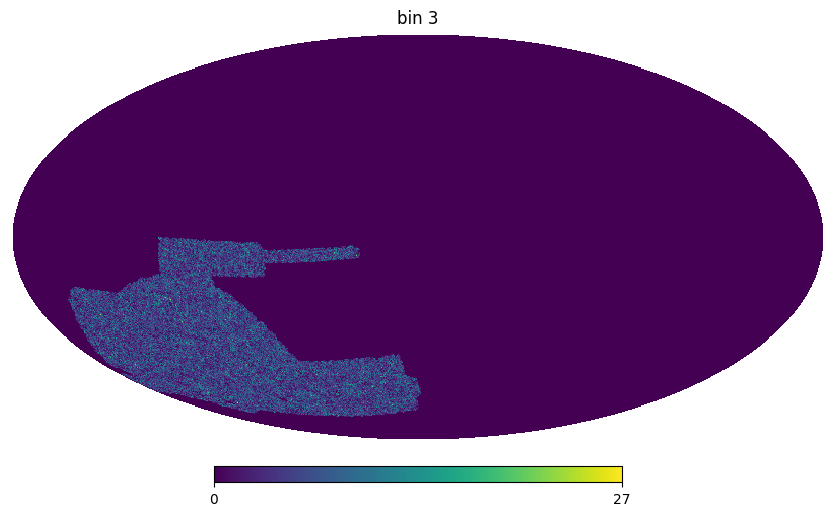

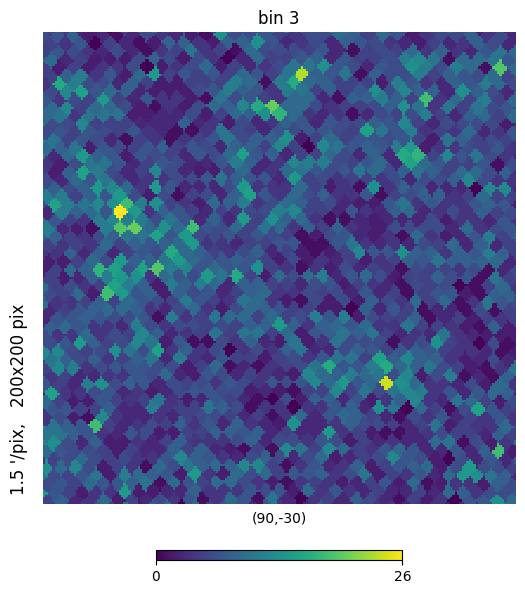

In [8]:
obs_file = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/mock_observations/DESY3_Buzzard_mock.h5"
label = f"Buzzard"

# obs_file = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/mock_observations/DESY3_Cardinal_mock.h5"
# label = f"Cardinal"

with h5py.File(obs_file, "r") as f:
    gc_map = []
    for i in range(1,5):
        gc_map.append(f[f"maglim/galaxy_counts_bin{i}"][:])
    gc_map = np.stack(gc_map, axis=-1)
    
# to correct the apparently wrong galaxy number density in the mock
# gc_map *= 1.25
    
for i in range(gc_map.shape[-1]):
    hp.mollview(gc_map[:,i], title=f"bin {i}")
    hp.gnomview(gc_map[:,i], title=f"bin {i}", rot=(90, -30, 0))

obs_map, _ = observation.forward_model_observation_map(
    gc_count_map=gc_map,
    conf=msfm_conf,
    apply_norm=True,
    with_padding=True,
    nest=False,
)

# evaluate the network

In [9]:
obs_pred = model(obs_map[np.newaxis])
obs_pred = np.squeeze(obs_pred)

print(obs_pred)
with h5py.File(os.path.join(base_dir, model_dir, label + "_mock_pred.h5"), "w") as f:
    f.create_dataset("pred", data=obs_pred)

[ 0.1055279   0.02064588 -0.5097883   0.11432034  0.15718569]
